# Plot types

This notebook compares different plot types to visualize segment data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from rhythmic_segments import RhythmicSegments

import sys
sys.path.append('../')

from src.raster import raster_plot
from src.utils import load_synthetic_intervals, savefig, subplot_title, subplots_grid, set_mpl_style, get_line_props
set_mpl_style()
from src.patdur import duration_boundary

In [2]:
datasets = load_synthetic_intervals()
for d in datasets:
  	d['rs'] = RhythmicSegments.from_intervals(d['intervals'], length=2)

## Event plots

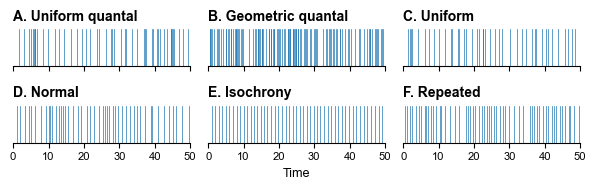

In [3]:
def show_event_plot(intervals, index, title, ax=None):
    if ax is not None: plt.sca(ax)
    for event in np.cumsum(intervals):
        plt.axvline(event, lw=.5)
    subplot_title(index, title)
    plt.xlim(0, 50)
    plt.yticks([])
    sns.despine(left=True)

fig, axs = subplots_grid(len(datasets), ratios=(2, 1), sharey=True, sharex=True)
for i, d in enumerate(datasets): 
	ax = axs.ravel()[i]
	show_event_plot(d['intervals'], i, d['name'].capitalize(), ax=ax)
axs[1, 1].set_xlabel('Time')

plt.tight_layout()
plt.savefig('../figures/plot-types/event-plots.pdf')

## Raster plots

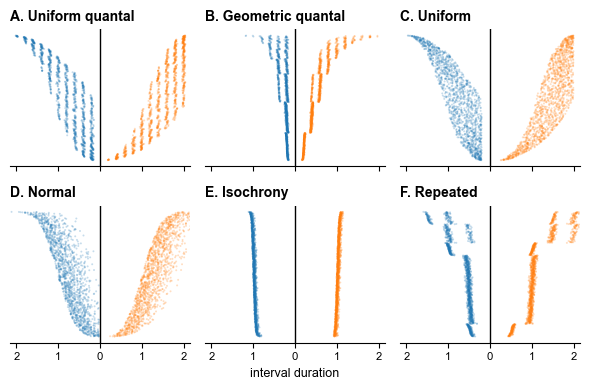

In [4]:
def raster_subplot(rs, s=2, ax=None, **kws):
    if ax is not None: plt.sca(ax)
    raster_plot(rs, s=s, xlabel='', **kws)

fig, axs = subplots_grid(len(datasets), ratios=(2, 2), sharex=True)
for i, d in enumerate(datasets): 
    ax = axs.ravel()[i]
    subplot_title(i, d['name'].capitalize(), ax=ax)
    raster_subplot(d['rs'], ax=ax)

axs[1,1].set_xlabel('interval duration')
plt.tight_layout()
plt.savefig('../figures/plot-types/raster-plots.pdf')

## Phase-plot

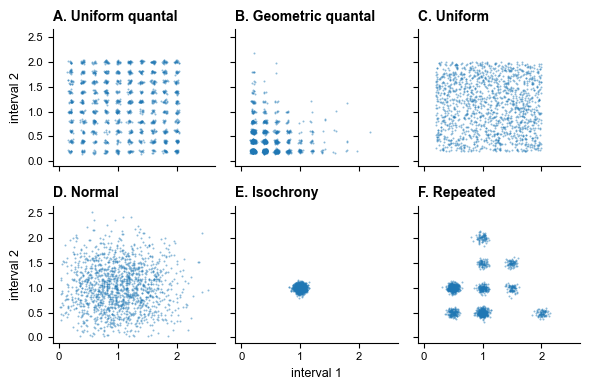

In [5]:
def phase_subplot(rs, ax=None, s=2, **kws):
	ax = ax or plt.gca()
	sns.scatterplot(x=rs.segments[:, 0], y=rs.segments[:, 1], s=s, lw=0, alpha=.5, ax=ax, **kws)
	sns.despine(ax=ax)

fig, axs = subplots_grid(len(datasets), ratios=(2, 2), sharey=True, sharex=True)
for i, d in enumerate(datasets): 
	ax = axs.ravel()[i]
	subplot_title(i, d['name'].capitalize(), ax=ax)
	phase_subplot(d['rs'], ax=ax)

axs[1,1].set_xlabel('interval 1')
axs[0,0].set_ylabel('interval 2')
axs[1,0].set_ylabel('interval 2')
plt.tight_layout()
plt.savefig('../figures/plot-types/phase-plots-scatter.pdf')

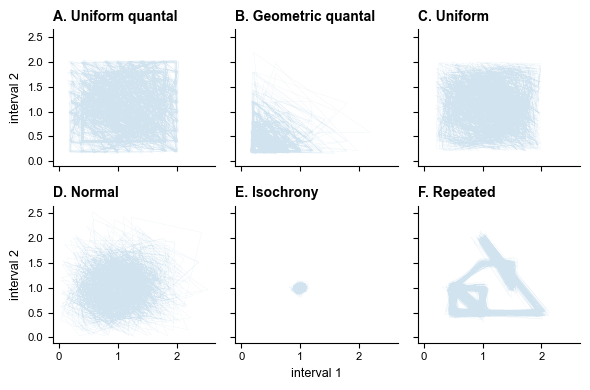

In [6]:
def phase_subplot_trajectories(rs, ax=None, s=2, **kws):
	ax = ax or plt.gca()
	ax.plot(rs.segments[:, 0], rs.segments[:, 1], lw=.1, alpha=.2, **kws)
	sns.despine(ax=ax)

fig, axs = subplots_grid(len(datasets), ratios=(2, 2), sharey=True, sharex=True)
for i, d in enumerate(datasets): 
	ax = axs.ravel()[i]
	subplot_title(i, d['name'].capitalize(), ax=ax)
	phase_subplot_trajectories(d['rs'], ax=ax)

axs[1,1].set_xlabel('interval 1')
axs[0,0].set_ylabel('interval 2')
axs[1,0].set_ylabel('interval 2')
plt.tight_layout()
plt.savefig('../figures/plot-types/phase-plots-trajectory.pdf')

## Pattern-duration plot

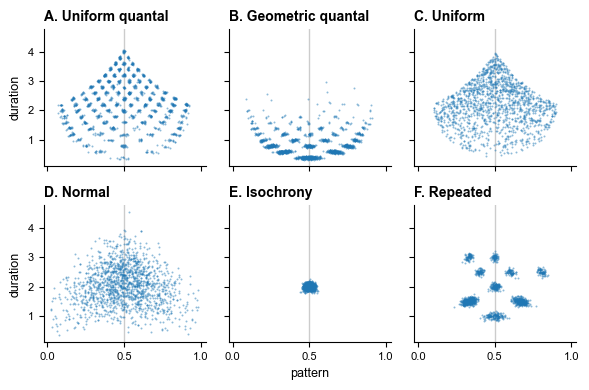

In [7]:
def patdur_subplot(rs, ax=None, s=2, **kws):
	ax = ax or plt.gca()
	sns.scatterplot(x=rs.patterns[:, 0], y=rs.durations, s=s, lw=0, alpha=.5, ax=ax, **kws)
	sns.despine(ax=ax)
	ax.axvline(0.5, lw=1, c='0.8', zorder=0)

fig, axs = subplots_grid(len(datasets), ratios=(2, 2), sharey=True, sharex=True)
for i, d in enumerate(datasets): 
	ax = axs.ravel()[i]
	subplot_title(i, d['name'].capitalize(), ax=ax)
	patdur_subplot(d['rs'], ax=ax)

axs[1,1].set_xlabel('pattern')
axs[0,0].set_ylabel('duration')
axs[1,0].set_ylabel('duration')
plt.tight_layout()
plt.savefig('../figures/plot-types/pattern-duration.pdf')

## Ratio plots

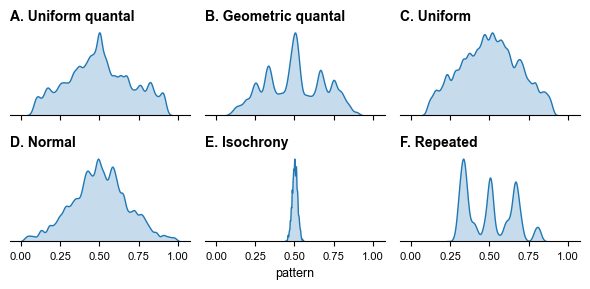

In [8]:
def ratio_subplot(rs, ax=None, bw_adjust=1/3, **kws):
	ax = ax or plt.gca()
	sns.kdeplot(x=rs.patterns[:, 0], fill=True, bw_adjust=bw_adjust, ax=ax, **kws)
	sns.despine(ax=ax, left=True)
	ax.set_yticks([])
	ax.set_ylabel('')

fig, axs = subplots_grid(len(datasets), ratios=(2, 1.5), sharex=True)
for i, d in enumerate(datasets): 
	ax = axs.ravel()[i]
	subplot_title(i, d['name'].capitalize(), ax=ax)
	ratio_subplot(d['rs'], ax=ax)

axs[1,1].set_xlabel('pattern')

plt.tight_layout()
plt.savefig('../figures/plot-types/ratio-plots.pdf')

## Combined

TypeError: seaborn.relational.scatterplot() got multiple values for keyword argument 'alpha'

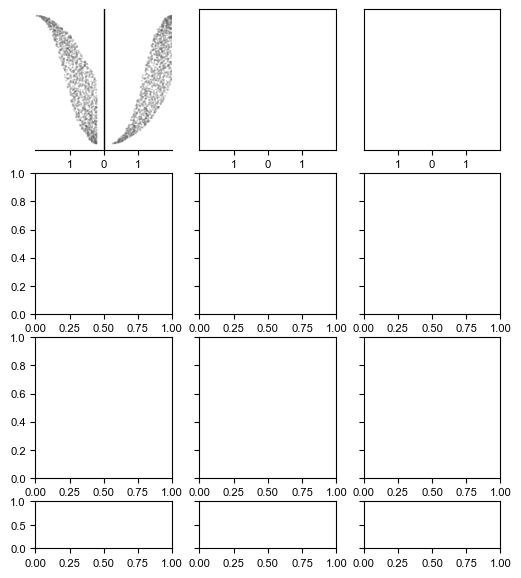

In [9]:
fig, axs = plt.subplots(
    figsize=(6, 7), 
    nrows=4, ncols=3, 
    sharey='row',
    sharex='row',
    height_ratios=[3, 3, 3, 1],
    # gridspec_kw=dict(hspace=.5)
)
scatter_kws = dict(alpha=.3, c='0.4', lw=0)

for i, idx in enumerate([2, 1, 5]):
    dataset = datasets[idx]
    raster_subplot(dataset['rs'], ax=axs[0, i], **scatter_kws)
    phase_subplot(dataset['rs'], ax=axs[1, i], **scatter_kws)
    patdur_subplot(dataset['rs'], ax=axs[2, i], **scatter_kws)
    ratio_subplot(dataset['rs'], ax=axs[3, i], color=scatter_kws['c'])

# Min- and max duration boundaries in pat-dur plot
l1, = duration_boundary(0.2, 'min', ax=axs[2, 0], linewidth=1, ls='--', color="k")
l2, = duration_boundary(2, 'max', ax=axs[2, 0], linewidth=1, ls=':', color="k")

# Min- and max duration boundaries in phase-plot
axs[1, 0].plot([.2, .2, 10], [10, .2, .2], **get_line_props(l1))
axs[1, 0].plot([0, 2, 2], [2, 2, 0], **get_line_props(l2))

# Titles
col_title_kws = dict(ha='left', x=0, fontweight='bold')
axs[0, 0].set_title('1. Uniform', **col_title_kws)
axs[0, 1].set_title('2. Quantal', **col_title_kws)
axs[0, 2].set_title('3. Repeated', **col_title_kws)

title_kws = dict(
    xy=(-.3, 0.5), xycoords='axes fraction', rotation=90,
    va='center', ha='right', fontsize=9, fontweight='bold'
)
axs[0, 0].annotate('A. Raster plot', **title_kws)
axs[1, 0].annotate('B. Phase plot', **title_kws)
axs[2, 0].annotate('C. Pattern-duration', **title_kws)
axs[3, 0].annotate('D. Ratio plot', **title_kws)

# Raster plots
annot_kws = dict(xycoords='axes fraction', fontsize=8)
for col in range(0, axs.shape[1]):
    if col == 0:
        left = '$\leftarrow$ short interval'
        right = 'long interval $\\rightarrow$' 
    else:
        left = '$\leftarrow$ short'
        right = 'long $\\rightarrow$'
    axs[0, col].annotate(left, xy=(.48, -.22), ha='right', **annot_kws)
    axs[0, col].annotate(right, xy=(.52, -.22), ha='left', **annot_kws)

annot_kws['rotation'] = 90
axs[0, 0].annotate('$\leftarrow$ faster', xy=(-.1, .1), va='bottom', ha='left', **annot_kws)
axs[0, 0].annotate('slower $\\rightarrow$', xy=(-.1, .9), va='top', ha='left', **annot_kws)

# Phase plot
for col in range(0, axs.shape[1]):
    axs[1, col].set_xlabel('interval 1')
    axs[1, col].plot([0, 10], [0, 10], color='0.8', lw=0.5, zorder=-1)
axs[1, 0].set_ylabel('interval 2')
axs[1, 0].set_xlim(0, 2.5)
axs[1, 0].set_ylim(0, 2.5)
axs[1, 0].set_yticks([0, 1, 2])

# Pat-dur plot
axs[2, 0].set_ylabel('duration')
axs[2, 0].set_ylim(0, 4)
axs[2, 0].set_xlim(0, 1)
axs[2, 0].set_xticks([0, .5, 1])

# Ratio plots
axs[3, 0].set_ylabel('density')
axs[3, 0].set_xlim(axs[2, 0].get_xlim())
axs[3, 0].set_xticks(axs[2,0].get_xticks())
for col in range(0, axs.shape[1]):
    axs[3, col].set_xlabel('pattern')

plt.tight_layout()

# Connecting lines to show the x-axes of the last two rows are shared
row = 3
for col in range(3):
    x0 = axs[row, col].get_position().x0
    x1 = axs[row, col].get_position().x1
    y0 = axs[row, col].get_position().y0
    y1 = axs[row-1, col].get_position().y0 - .03
    line_kws= dict(transform=fig.transFigure, lw=1, c='.5', ls=":")
    fig.add_artist(Line2D([x0, x0], [y0, y1], **line_kws))
    fig.add_artist(Line2D([x1, x1], [y0, y1], **line_kws))

# plt.savefig('../figures/synthetic-data-combined.pdf')
